# 흩어진 테이블, 하나의 인사이트로

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🔗 흩어진 테이블, 하나의 인사이트로 — 병합·집계·피벗

### — 따로 노는 표들을 하나로 잇고, 그룹별로 요약하고, 보기 좋은 모양으로 바꾸는 법 —

---

## 📋 학습 목표

이 자습서를 마치면 여러분은 다음을 할 수 있습니다.

1. `merge`·`join`·`concat`이 각각 어떻게 동작하는지, 그리고 조인 유형(inner·left·right·outer)이 어떻게 다른지 설명할 수 있습니다.
2. `groupby`·`agg`·`transform`의 역할 차이를 알고, wide ↔ long 변환이 무엇인지 설명할 수 있습니다.
3. 목적에 맞는 결합 방식과 조인 유형을 골라 여러 테이블을 합칠 수 있습니다.
4. 집계 형태에 따라 `groupby`·`agg`·`transform`을 구분해서 적용할 수 있습니다.
5. `pivot_table`·`stack`/`unstack`으로 표의 모양(포맷)을 자유롭게 바꿀 수 있습니다.
6. 매출·고객·상품 테이블을 병합해 월별 KPI 요약표를 완성하고 GitHub에 제출할 수 있습니다.
7. 테이블을 합치기 전에 **키·중복·결측을 먼저 검증**하는 습관을 들일 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 내가 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 자습서를 다 마친 뒤 다시 돌아와 비교하면 여러분의 성장이 눈에 보일 거예요.

## 📚 목차

| Part | 내용 | 핵심 질문 |
| --- | --- | --- |
| Part 0 | 분석 상황과 학습 지도 | 흩어진 표들을 어떻게 하나로 모을까요? |
| Part 1 | concat — 위아래·옆으로 이어 붙이기 | 같은 모양의 데이터 조각을 어떻게 합칠까요? |
| Part 2 | merge — 키로 연결하기 (+ 조인 유형) | 서로 다른 정보를 어떻게 짝지을까요? |
| Part 3 | 병합 전 키 검증 | 합치기 전에 무엇을 반드시 확인해야 할까요? |
| Part 4 | groupby + agg — 그룹별 요약 | 전체 말고 그룹별로 어떻게 요약할까요? |
| Part 5 | transform — 그룹 통계를 행에 되돌리기 | 그룹 평균을 각 행 옆에 붙이려면? |
| Part 6 | pivot_table & wide/long | 표의 모양 자체를 바꾸려면? |
| 종합 실습 | 월별 KPI 요약표 | 세 테이블을 합쳐 경영 보고서를 만들 수 있을까요? |
| 정리 | 핵심 요약 · 다음 시간 | 합쳐진 데이터, 다음엔 무엇을 해야 할까요? |

## 분석 상황과 학습 지도

# 0. 분석 상황과 학습 지도

## 지난 시간에는 무엇을 했나요?

바로 전 시간에는 **한 장의 표를 깨끗하게 만드는 법**을 배웠습니다. 결측치(missing value)가 왜 생겼는지 유형(MCAR·MAR·MNAR)을 따져 처리 전략을 정하고, IQR로 이상치(outlier)를 찾아내 제거할지 남길지 판단했습니다. 핵심 태도도 하나 익혔죠 — **"왜 이 방법인가"를 노트북에 기록하는 습관**입니다.

즉, 지금 여러분의 손에는 **잘 닦인 표 한 장**이 있습니다. 그런데 현실의 분석은 표 한 장으로 끝나지 않습니다.

## 오늘의 여정

회사의 데이터는 보통 **여러 표에 흩어져** 있습니다. 주문은 주문대로, 고객은 고객대로, 상품은 상품대로 따로 저장돼 있죠. "프리미엄 회원이 어떤 카테고리를 많이 사는가?" 같은 질문에 답하려면 이 흩어진 표들을 **하나로 이어 붙이고**, **그룹별로 묶어 요약하고**, **보기 좋은 표로 바꿔야** 합니다.

오늘은 그 세 가지 기술을 순서대로 배웁니다.

```text
[Part 1] concat        →  같은 모양의 조각을 위아래·옆으로 이어 붙이기
   ↓
[Part 2] merge         →  서로 다른 정보를 '키'로 짝지어 연결하기 (조인 유형)
   ↓
[Part 3] 키 검증        →  합치기 전에 키·중복·결측을 먼저 확인하기
   ↓
[Part 4] groupby + agg →  그룹별로 나눠 요약 통계 내기
   ↓
[Part 5] transform     →  그룹 통계를 원래 행 옆에 되돌려주기
   ↓
[Part 6] pivot_table   →  표의 모양(wide/long)을 자유롭게 바꾸기
   ↓
[종합 실습] 월별 KPI 요약표 → 세 테이블을 합쳐 경영 보고서 만들기
```

## 이 자습서 사용법

이 노트북은 **혼자서도 끝까지 학습할 수 있도록** 만들었습니다. 다음 네 박자로 진행하세요.

- 📖 **읽고** — 개념 설명을 천천히 읽습니다.
- 💻 **실행하고** — 코드 셀을 위에서부터 순서대로 실행합니다. (단축키: `Shift + Enter`)
- ✏️ **고쳐보고** — "스스로 해보자!" 칸에서 코드를 직접 바꿔봅니다.
- 🤔 **답해보고** — 체크포인트 질문에 스스로 답해봅니다. 틀려도 괜찮습니다.

> ⚠ **주의:** 코드 셀은 반드시 **위에서부터 순서대로** 실행해야 합니다. 중간 셀을 건너뛰면 "앞에서 만든 변수가 없다"는 오류가 날 수 있어요. 오류는 잘못이 아니라 디버깅의 단서입니다. 천천히 읽어가세요.

## 오늘의 무대: 가상의 이커머스 "모두마켓"

지난 시간에 이어, 오늘도 우리는 가상의 온라인 쇼핑몰 **모두마켓**의 데이터 분석가입니다. 그런데 오늘은 동료가 데이터를 **세 개의 파일로 따로따로** 건네줍니다.

> "주문 기록은 `orders`, 고객 정보는 `customers`, 상품 정보는 `products`에 있어요. 이 셋을 합쳐서 **'어떤 고객층이 어떤 상품을 얼마나 사는지'** 한 장으로 정리해줄 수 있을까요?"

바로 이것이 오늘의 미션입니다. 세 표는 각각 다음을 담고 있습니다.

| 테이블 | 한 행(row)이 뜻하는 것 | 핵심 컬럼 | 다른 표와 잇는 키(key) |
| --- | --- | --- | --- |
| `orders` (주문) | 주문 1건 | `quantity`, `amount`, `order_date` | `customer_id`, `product_id` |
| `customers` (고객) | 고객 1명 | `age`, `gender`, `region`, `membership` | `customer_id` |
| `products` (상품) | 상품 1종 | `category`, `price` | `product_id` |

> 💡 **핵심 개념 미리보기 — '키(key)':** 표와 표를 잇는 **공통 열**을 키라고 합니다. `orders`의 `customer_id`와 `customers`의 `customer_id`가 같은 값이면 "이 주문은 이 고객의 것"이라고 연결할 수 있죠. 엑셀의 `VLOOKUP`을 떠올리면 됩니다.

> **🎯 오늘의 핵심**
> **합치기 전에 키부터 검증합니다.** 무턱대고 합치면 행이 불어나거나 사라져도 눈치채지 못합니다. 분석가의 첫 행동은 합치는 것이 아니라, "이 키로 합쳐도 되는가"를 확인하는 것입니다.

아래 셀을 실행하면 모두마켓의 세 테이블이 만들어집니다. **이 노트북은 이 셀 하나로 단독 실행됩니다** — 지난 시간 결과물이 없어도 괜찮습니다.

> **읽는 법:** `orders`에는 `customer_id`와 `product_id`라는 **두 개의 키**가 있습니다. 하지만 정작 "이 고객의 나이는?", "이 상품의 카테고리는?"은 `orders`만 봐서는 알 수 없죠. 그 정보는 `customers`와 `products`에 따로 있으니까요.
>
> 그래서 오늘의 첫 큰 그림은 이렇습니다: **`orders`를 가운데 두고, `customer_id`로 `customers`를, `product_id`로 `products`를 양옆에 이어 붙인다.** 그러면 한 행에 "누가 / 무엇을 / 얼마에 / 언제" 샀는지가 모두 모입니다.

이제 가장 단순한 합치기부터 시작합니다. 모양이 같은 조각을 그냥 **이어 붙이는** `concat`입니다.

In [47]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.5.0
pandas: 3.0.3


In [48]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 세 테이블이 모두 준비됩니다.
# 오늘의 초점은 '병합'이므로, 날짜는 분석 가능한 형태(datetime)로 깔끔하게 둡니다.
# (문자열·날짜 오염 정제는 다음 시간 D+005의 주제입니다.)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) — 고객 1명이 한 행
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int).clip(18, 70),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})

# 2) 상품(products) — 상품 1종이 한 행
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 주문 1건이 한 행. customer_id·product_id로 위 두 표와 연결됩니다.
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity
order_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D")

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
    "order_date": order_dates,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (300, 5) | products: (40, 3) | orders: (2000, 7)


In [49]:
# 세 테이블의 첫인상을 잡아봅니다. 어떤 컬럼이 공통(키)인지 눈으로 찾아보세요.
print("=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===")
display(orders.head())
print("\n=== customers (고객) — customer_id가 키 ===")
display(customers.head(3))
print("\n=== products (상품) — product_id가 키 ===")
display(products.head(3))

=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00003,C0115,P034,1,49900.0,app,2025-02-26
3,O00004,C0186,P029,1,89900.0,web,2025-01-24
4,O00005,C0056,P004,3,149700.0,web,2025-02-22



=== customers (고객) — customer_id가 키 ===


,customer_id,age,gender,region,membership
0,C0001,39,M,경기,premium
1,C0002,34,F,부산,basic
2,C0003,41,F,서울,premium



=== products (상품) — product_id가 키 ===


,product_id,category,price
0,P001,가전,89900
1,P002,식품,9900
2,P003,도서,9900


## concat — 같은 모양의 데이터를 이어 붙이기

# 1. concat — 같은 모양의 데이터를 이어 붙이기

현장에서 데이터는 종종 **조각으로 나뉘어** 옵니다. "1월 주문.csv", "2월 주문.csv"처럼 월별로 파일이 따로 있거나, 부서별로 같은 양식의 표를 따로 관리하기도 하죠. 분석하려면 이 조각들을 **하나로 합쳐야** 합니다.

가장 단순한 합치기는 **모양(컬럼)이 똑같은 표를 그냥 이어 붙이는 것**입니다. 이때 쓰는 도구가 `concat`(concatenate, 연결하다)입니다.

> ❓ **이 파트에서 답할 질문:** 컬럼 구조가 같은 데이터 조각들을 어떻게 하나로 모을까요?

## 💡 쉽게 말하면 — 종이를 위아래로 잇기 vs 옆으로 잇기

`concat`은 종이를 풀로 이어 붙이는 것과 같습니다. 붙이는 방향이 두 가지예요.

```text
[세로로 잇기 axis=0]              [가로로 잇기 axis=1]
 1월 주문                          기본정보 | + | 추가정보
 ┌────────┐                       ┌──────┐   ┌──────┐
 │ 행1    │                       │ 이름 │   │ 나이 │
 │ 행2    │                       │ 홍길동│ + │  35  │
 └────────┘                       └──────┘   └──────┘
    +  (아래에 붙임)
 2월 주문                          → 행은 그대로, 열이 늘어남
 ┌────────┐
 │ 행3    │
 │ 행4    │
 └────────┘
 → 열은 그대로, 행이 늘어남
```

대부분의 실무에서는 **세로로 잇기(`axis=0`)** 를 씁니다. "같은 양식의 기록을 행으로 쌓는다"가 가장 흔한 상황이니까요.

## 자세히 알아보기

`pd.concat([표1, 표2, ...])`는 리스트로 받은 표들을 차례로 이어 붙입니다.

| 옵션 | 의미 | 언제 쓰나 |
| --- | --- | --- |
| `axis=0` (기본값) | 위아래(행 방향)로 쌓기 | 같은 컬럼의 기록을 누적할 때 |
| `axis=1` | 좌우(열 방향)로 붙이기 | 같은 행에 다른 컬럼을 추가할 때 |
| `ignore_index=True` | 합친 뒤 인덱스를 0부터 다시 매김 | 원래 인덱스가 의미 없을 때 (대부분) |
| `keys=[...]` | 어느 조각에서 왔는지 라벨 달기 | 출처를 구분해야 할 때 |

> ⚠ **주의:** `concat`은 **키로 짝짓는 게 아니라 그냥 갖다 붙입니다.** 그래서 컬럼 이름이 서로 다르면 빈칸(`NaN`)이 생깁니다. "같은 모양일 때만 쓴다"가 핵심입니다.

## 데이터로 확인해 봅시다

모두마켓의 주문이 **1월/2월 파일로 나뉘어** 있다고 해봅시다. `order_date`를 기준으로 둘로 쪼갠 뒤, 다시 `concat`으로 합쳐보겠습니다.

> **읽는 법:** `concat`은 단순합니다. 1월 1,000건 + 2월 500건이면 합쳐서 정확히 1,500건이 됩니다(행이 그대로 누적). `keys`를 주면 합친 뒤에도 "이 행은 1월에서 왔다"를 인덱스로 구분할 수 있어요.
>
> 핵심은 **`concat`은 "같은 모양"을 전제**한다는 점입니다. 컬럼이 똑같으니 그냥 쌓으면 되죠. 그런데 만약 합치려는 두 표의 컬럼이 **서로 다르다면**? 예를 들어 `orders`(주문 정보)와 `customers`(고객 정보)는 컬럼이 완전히 다릅니다. 이럴 땐 `concat`이 아니라 **키로 짝짓는 `merge`** 가 필요합니다.

> 📌 **다른 산업에서는?** `concat`은 금융에서 일자별 거래 로그를 월말에 한 파일로 합칠 때, 제조에서 라인별 품질 측정 기록을 공장 단위로 모을 때, 마케팅에서 캠페인별 성과 시트를 분기 단위로 쌓을 때에도 똑같이 쓰입니다.

### 스스로 해보자! ✏️ (1)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`orders`를 **3월 주문(`order_date`의 월이 3)** 과 **4월 주문(월이 4)** 으로 각각 나눈 뒤, `concat`으로 하나로 합치고, 합친 표의 행 수가 "3월 행 수 + 4월 행 수"와 같은지 확인해보세요.

<details>
<summary>💡 힌트 (클릭)</summary>

```python
orders_mar = orders[orders["order_date"].dt.month == 3].copy()
orders_apr = orders[orders["order_date"].dt.month == 4].copy()

orders_3_4 = pd.concat([orders_mar, orders_apr], axis=0, ignore_index=True)

print("3월:", len(orders_mar), "+ 4월:", len(orders_apr), "=", len(orders_mar) + len(orders_apr))
print("합친 결과:", len(orders_3_4))
```

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. `concat(axis=0)`과 `concat(axis=1)`은 각각 무엇이 늘어나나요? (행? 열?)
(1) 각각 세로(행), 가로(열) 늘어납니다

2. `ignore_index=True`는 왜 자주 쓸까요?
(2) 정렬을 위해

3. 컬럼 구조가 **서로 다른** 두 표(예: 주문 정보 vs 고객 정보)를 합치려 할 때 `concat`이 적절하지 않은 이유는 무엇일까요?
(3) concat은 그냥 갖다 붙이기 때문에 컬럼이 동일할 때만 사용해야 합니다. 서로 다르면 nan이 생깁니다!

> 💡 **다음 Part 예고:** `concat`은 "같은 모양"만 이어 붙입니다. 하지만 우리의 진짜 미션은 **컬럼이 전혀 다른** `orders`와 `customers`를 잇는 것이죠. 이때는 **공통 키로 짝짓는 `merge`** 가 필요합니다. 바로 다음에서 배웁니다.

In [50]:
# 예제: 월별로 쪼개진 주문 파일을 흉내 내기 — orders를 1월/2월로 나눕니다.
orders_jan = orders[orders["order_date"].dt.month == 1].copy()
orders_feb = orders[orders["order_date"].dt.month == 2].copy()

print("1월 주문:", orders_jan.shape, "| 2월 주문:", orders_feb.shape)

# 세로로 이어 붙이기(axis=0). ignore_index=True로 인덱스를 0부터 다시 매깁니다.
orders_1_2 = pd.concat([orders_jan, orders_feb], axis=0, ignore_index=True)
print("합친 결과:", orders_1_2.shape, "  ← 1월 행 수 + 2월 행 수")
display(orders_1_2.head(3))

1월 주문: (545, 7) | 2월 주문: (435, 7)
합친 결과: (980, 7)   ← 1월 행 수 + 2월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00004,C0186,P029,1,89900.0,web,2025-01-24


In [51]:
# 예제: keys로 '어느 달에서 왔는지' 라벨 달기
# 합친 뒤 출처를 구분해야 할 때 유용합니다.
labeled = pd.concat(
    [orders_jan, orders_feb],
    keys=["2025-01", "2025-02"],   # 바깥 인덱스로 출처 라벨이 붙습니다.
    names=["월", None],
)
print("바깥 인덱스(월)로 출처가 구분됩니다:")
display(labeled.head(3))

# 각 달이 몇 건인지 바깥 인덱스로 세어보기
print("\n월별 주문 건수:")
print(labeled.groupby(level="월").size())

바깥 인덱스(월)로 출처가 구분됩니다:


order_id customer_id product_id  quantity   amount channel  \
월                                                                      
2025-01 0   O00001       C0040       P017         1  19900.0     web   
        1   O00002       C0224       P022         1  89900.0     app   
        3   O00004       C0186       P029         1  89900.0     web   

          order_date  
월                     
2025-01 0 2025-01-03  
        1 2025-01-26  
        3 2025-01-24


월별 주문 건수:
월
2025-01    545
2025-02    435
dtype: int64


In [52]:
# 스스로 해보자! (1)
# 1) 3월 주문, 4월 주문을 각각 만들어 보세요.
orders_mar = orders[orders["order_date"].dt.month == 3].copy()
orders_apr = orders[orders["order_date"].dt.month == 4].copy()
print("3월 주문:", orders_mar.shape, "| 4월 주문:", orders_apr.shape)

# 2) 두 표를 concat으로 합쳐 보세요 (ignore_index=True 권장).
orders_3_4 = pd.concat([orders_mar, orders_apr], axis=0, ignore_index=True)

# 3) 행 수를 비교해 출력해 보세요.
print("합친 결과:", orders_3_4.shape, "  ← 3월 행 수 + 4월 행 수")
display(orders_3_4.head(3))

3월 주문: (521, 7) | 4월 주문: (499, 7)
합친 결과: (1020, 7)   ← 3월 행 수 + 4월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00006,C0040,P005,1,129900.0,web,2025-03-11
1,O00008,C0237,P021,2,19800.0,web,2025-03-01
2,O00012,C0147,P019,1,19900.0,web,2025-03-17


## merge — 서로 다른 정보를 키로 연결하기

# 2. merge — 서로 다른 정보를 키로 연결하기

`orders` 한 장만 보면 "주문 O00001은 고객 C0042가 상품 P012를 2개 샀다"까지만 알 수 있습니다. **이 고객이 몇 살인지, 어느 지역인지, 이 상품이 어떤 카테고리인지**는 `orders`에 없습니다. 그 정보는 `customers`와 `products`에 따로 있죠.

이렇게 **서로 다른 정보를 가진 표를, 공통 키를 기준으로 짝지어 잇는** 것이 `merge`입니다. 엑셀의 `VLOOKUP`을 한 번에, 표 전체에 적용하는 것이라고 보면 됩니다.

> ❓ **이 파트에서 답할 질문:** 컬럼이 서로 다른 두 표를, 공통된 키를 기준으로 어떻게 짝지어 합칠까요?

## 💡 쉽게 말하면 — 열쇠와 자물쇠

`merge`는 **열쇠(키)로 짝을 찾는** 작업입니다.

```text
 orders                         customers
 order_id customer_id           customer_id  age  region
 O00001   C0042  ────열쇠────►  C0042        29   서울
 O00002   C0007  ────열쇠────►  C0007        41   부산

 → customer_id가 같은 행끼리 짝지어, 한 줄로 합칩니다.

 결과:
 order_id customer_id  age  region
 O00001   C0042        29   서울
 O00002   C0007        41   부산
```

`orders`의 `customer_id` 값을 들고 `customers`로 가서 **같은 값을 가진 행을 찾아** 그 옆에 붙이는 것이죠.

## 자세히 알아보기 — merge와 조인 유형

`pd.merge(왼쪽표, 오른쪽표, on="키컬럼", how="조인유형")` 형태로 씁니다. 여기서 **`how`(조인 유형)** 가 가장 중요합니다. "양쪽에 다 있는 키만 남길까, 한쪽 기준으로 다 남길까"를 결정하거든요.

| how | 뜻 | 남는 행 | 언제 쓰나 |
| --- | --- | --- | --- |
| `inner` (기본값) | 교집합 | **양쪽 모두**에 있는 키만 | 짝이 맞는 것만 보고 싶을 때 |
| `left` | 왼쪽 기준 | **왼쪽은 전부** + 오른쪽은 맞는 것만 | 왼쪽 표를 기준으로 정보 덧붙일 때 (가장 흔함) |
| `right` | 오른쪽 기준 | 오른쪽은 전부 + 왼쪽은 맞는 것만 | `left`의 거울. 자주 안 씀 |
| `outer` | 합집합 | **어느 한쪽에라도** 있으면 전부 | 누락을 찾아내고 싶을 때 |

> 💡 **개념 연결:** `how`를 고르는 건 지난 시간의 **결측 처리 판단**과 같은 결의 결정입니다. `left` 조인에서 오른쪽 짝이 없으면 그 자리에 `NaN`(결측)이 생깁니다. 즉 "어떻게 합치는가"가 "어디에 결측을 만드는가"를 결정합니다.

## 데이터로 확인해 봅시다

`orders`(왼쪽)에 `customers`(오른쪽)의 정보를 `customer_id`로 붙여봅시다. 기준은 **주문 전부를 살리는** `left` 조인입니다.

> **읽는 법:** 병합 후 행 수(2000)는 그대로인데 **열이 늘었습니다.** `orders`의 각 행 옆에 그 고객의 `age`, `gender`, `region`, `membership`이 붙었죠. 이제 한 행만 봐도 "29세 서울 프리미엄 회원이 P012를 2개 샀다"를 알 수 있습니다.

이제 조인 유형 4종이 **결과 행 수**를 어떻게 바꾸는지 작은 예제로 직접 비교해봅시다. 일부러 **짝이 안 맞는 키**를 넣은 미니 표를 만들겠습니다.

> **읽는 법:** 같은 두 표인데 `how`만 바꿔도 결과가 완전히 달라집니다.
> - `inner`: 양쪽에 다 있는 `B, C`만 → **2행**
> - `left`: 왼쪽 전부 `A, B, C` → `A`는 오른쪽 짝이 없어 `right_val`이 `NaN` → **3행**
> - `right`: 오른쪽 전부 `B, C, D` → `D`는 왼쪽 짝이 없어 `left_val`이 `NaN` → **3행**
> - `outer`: 한쪽에라도 있으면 전부 `A, B, C, D` → **4행**, 짝 없는 칸은 `NaN`
>
> 즉 **`how` 선택은 곧 "어떤 행을 남기고, 어디에 결측을 만들 것인가"** 의 결정입니다.

아래는 네 조인 유형을 벤다이어그램으로 그린 그림입니다.

> **읽는 법:** 파란색으로 칠해진 영역이 결과에 **남는 부분**입니다. `inner`는 겹치는 가운데만, `left`는 왼쪽 원 전체, `outer`는 두 원 전체. 실무에서 "기준이 되는 표(보통 거래·주문 기록)를 다 살리고 싶다"면 거의 항상 `left`를 씁니다.

> 📌 **다른 산업에서는?** `merge`는 헬스케어에서 환자ID로 진료기록과 검사결과를 잇고, 금융에서 계좌번호로 거래내역과 고객등급을 잇고, 마케팅에서 사용자ID로 광고 클릭 로그와 가입 정보를 이을 때에도 똑같이 쓰입니다. 키 하나로 흩어진 정보를 모으는 것은 모든 분석의 기본기입니다.

> 💡 **더 알고 싶다면 — `merge` vs `join` vs `concat`:** `df.join()`은 `merge`의 간편 버전으로, **인덱스를 키로 쓸 때** 편합니다(`on` 생략 가능). 내부 동작은 `merge`와 같아요. 키 컬럼으로 합치면 `merge`, 인덱스로 합치면 `join`, 같은 모양을 이어 붙이면 `concat` — 이렇게 기억하세요.

### 스스로 해보자! ✏️ (2)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

위에서 만든 `orders_cust`(orders + customers)에, 이번엔 **`products`까지** `product_id`로 병합해보세요. 그러면 한 행에 "고객 정보 + 상품 정보 + 주문 정보"가 모두 모입니다. `how="left"`로 주문을 전부 살리세요.

<details>
<summary>💡 힌트 (클릭)</summary>

```python
full = pd.merge(orders_cust, products, on="product_id", how="left")

print("병합 후:", full.shape)
print(list(full.columns))
display(full.head(3))
```

이제 `full`에는 누가(age·region·membership) 무엇을(category·price) 얼마나(quantity·amount) 언제(order_date) 샀는지가 한 행에 다 모였습니다.

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. `inner`와 `left`의 차이를 한 문장으로 설명할 수 있나요?
2. `left` 조인에서 오른쪽 짝이 없는 행은 어떻게 될까요?
3. "주문은 하나도 빠뜨리지 않고 고객 정보를 붙이고 싶다"면 어떤 `how`를 쓸까요?

> 💡 **다음 Part 예고:** 그런데 만약 `customers`에 **같은 `customer_id`가 두 번** 들어 있다면? 또는 `orders`의 어떤 `customer_id`가 `customers`에 **아예 없다면**? 합치고 나서야 "행이 갑자기 불어났다", "정보가 비어 있다"를 발견하면 늦습니다. 다음 Part에서 **합치기 전에 키를 검증하는 법**을 배웁니다.

In [53]:
# 예제: orders + customers를 customer_id로 병합 (left 조인)
# how="left": orders(왼쪽)는 전부 남기고, 각 주문에 해당 고객 정보를 붙입니다.
orders_cust = pd.merge(orders, customers, on="customer_id", how="left")

print("병합 전 orders:", orders.shape, "→ 병합 후:", orders_cust.shape)
print("컬럼이 늘었습니다:", list(orders_cust.columns))
display(orders_cust.head(3))

병합 전 orders: (2000, 7) → 병합 후: (2000, 11)
컬럼이 늘었습니다: ['order_id', 'customer_id', 'product_id', 'quantity', 'amount', 'channel', 'order_date', 'age', 'gender', 'region', 'membership']


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership
0,O00001,C0040,P017,1,19900.0,web,2025-01-03,37,M,경기,premium
1,O00002,C0224,P022,1,89900.0,app,2025-01-26,20,M,대구,premium
2,O00003,C0115,P034,1,49900.0,app,2025-02-26,33,M,경기,basic


In [54]:
# 예제: 조인 유형 4종 비교 — 일부러 '짝이 안 맞는' 작은 표로 차이를 봅니다.
left = pd.DataFrame({"id": ["A", "B", "C"], "left_val": [1, 2, 3]})
right = pd.DataFrame({"id": ["B", "C", "D"], "right_val": [20, 30, 40]})

print("왼쪽 표 (id: A,B,C)");  display(left)
print("오른쪽 표 (id: B,C,D)"); display(right)

for how in ["inner", "left", "right", "outer"]:
    merged = pd.merge(left, right, on="id", how=how)
    print(f"\n--- how='{how}' → {len(merged)}행 ---")
    display(merged)

왼쪽 표 (id: A,B,C)


,id,left_val
0,A,1
1,B,2
2,C,3


오른쪽 표 (id: B,C,D)


,id,right_val
0,B,20
1,C,30
2,D,40



--- how='inner' → 2행 ---


...

,id,left_val,right_val
0,A,1,NaN
1,B,2,20.0
2,C,3,30.0



--- how='right' → 3행 ---


,id,left_val,right_val
0,B,2.0,20
1,C,3.0,30
2,D,NaN,40



--- how='outer' → 4행 ---


,id,left_val,right_val
0,A,1.0,NaN
1,B,2.0,20.0
2,C,3.0,30.0
3,D,NaN,40.0


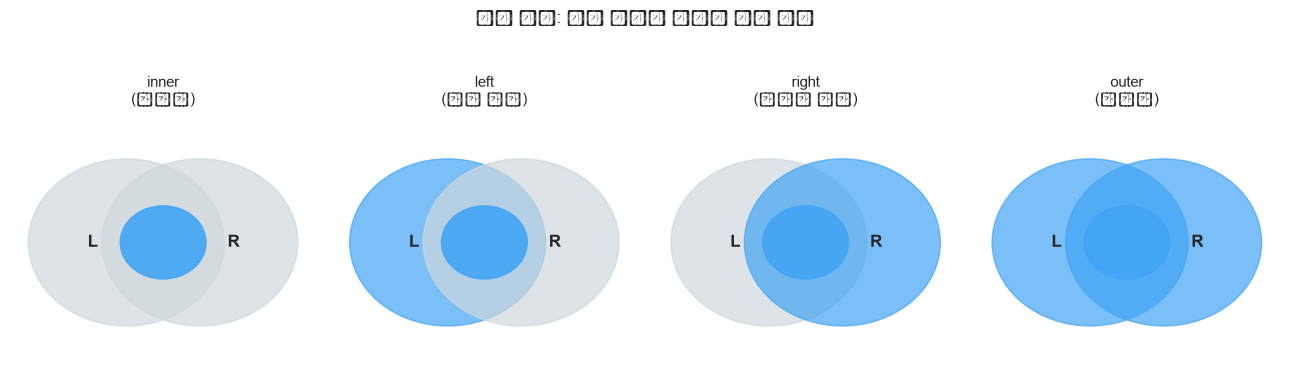

In [55]:
# ─────────────────────────────────────────────
# [도식] 조인 유형 4종을 벤다이어그램으로
# ─────────────────────────────────────────────
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
titles = ["inner\n(교집합)", "left\n(왼쪽 전부)", "right\n(오른쪽 전부)", "outer\n(합집합)"]
# (왼쪽칠, 교집합칠, 오른쪽칠)
fills = [(False, True, False), (True, True, False), (False, True, True), (True, True, True)]

for ax, title, (lf, mf, rf) in zip(axes, titles, fills):
    base = "#cfd8dc"
    hi = "#42a5f5"
    # 왼쪽 원
    ax.add_patch(Circle((0.38, 0.5), 0.32, color=hi if lf else base, alpha=0.7))
    # 오른쪽 원
    ax.add_patch(Circle((0.62, 0.5), 0.32, color=hi if rf else base, alpha=0.7))
    # 교집합은 색을 한 번 더 덧칠해 강조(겹침)
    if mf:
        ax.add_patch(Circle((0.5, 0.5), 0.14, color=hi, alpha=0.9))
    ax.text(0.27, 0.5, "L", ha="center", va="center", fontsize=12, weight="bold")
    ax.text(0.73, 0.5, "R", ha="center", va="center", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.suptitle("조인 유형: 파란 영역이 결과에 남는 부분", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

In [56]:
# 스스로 해보자! (2)
# orders_cust 에 products를 product_id로 left 병합해 보세요.
full = pd.merge(orders_cust, products, on="product_id", how="left")

# 병합 후 shape와 컬럼, head(3)를 확인해 보세요.
print("병합 전 orders_cust:", orders_cust.shape, "→ 병합 후:", full.shape)
print(list(full.columns))
display(full.head(3))

병합 전 orders_cust: (2000, 11) → 병합 후: (2000, 13)
['order_id', 'customer_id', 'product_id', 'quantity', 'amount', 'channel', 'order_date', 'age', 'gender', 'region', 'membership', 'category', 'price']


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership,category,price
0,O00001,C0040,P017,1,19900.0,web,2025-01-03,37,M,경기,premium,패션,19900
1,O00002,C0224,P022,1,89900.0,app,2025-01-26,20,M,대구,premium,식품,89900
2,O00003,C0115,P034,1,49900.0,app,2025-02-26,33,M,경기,basic,식품,49900


## 병합 전 키 검증 — 합치기 전에 반드시 확인할 것

# 3. 병합 전 키 검증 — 합치기 전에 반드시 확인할 것

> 처음 접하면 "이런 것까지 확인해야 하나?" 싶을 수 있습니다. 하지만 실무에서 병합 사고의 90%가 여기서 막을 수 있는 것들입니다. 천천히 읽어가세요.

`merge`는 강력하지만 위험합니다. **키에 문제가 있어도 오류 없이 조용히 잘못된 결과를 냅니다.** 대표적인 사고가 둘입니다.

1. **행 폭증(row explosion):** 오른쪽 표에 같은 키가 여러 번 있으면, 왼쪽 한 행이 여러 행으로 불어납니다. 매출이 2배, 3배로 부풀죠.
2. **조용한 결측:** 왼쪽 키가 오른쪽에 없으면 `left` 조인에서 그 자리가 `NaN`이 됩니다. 모르고 평균을 내면 엉뚱한 값이 나옵니다.

그래서 분석가는 **합치기 전에** 세 가지를 확인합니다: ① 키가 중복되는가, ② 짝이 안 맞는 키가 있는가, ③ 합친 뒤 행 수가 예상과 같은가.

> ❓ **이 파트에서 답할 질문:** 합치기 전에 무엇을 확인해야, 합친 뒤 결과를 믿을 수 있을까요?

## 💡 쉽게 말하면 — 표 사이의 '관계' 먼저 파악하기

두 표를 잇기 전에 **관계의 종류**를 알아야 합니다.

```text
1:1 관계   customers ─ customer_id ─ (고객정보 1줄)   ← 키가 양쪽에서 유일
1:N 관계   customers ─ customer_id ─ orders(여러 주문) ← 한 고객이 여러 주문
N:N 관계   (양쪽 다 키 중복)                          ← 위험! 행이 곱셈으로 폭증
```

`orders`와 `customers`는 **N:1 관계**입니다(한 고객이 여러 주문). `customer_id`가 `customers`에선 유일하지만 `orders`에선 여러 번 나오죠. 이게 정상입니다. 문제는 **유일해야 할 쪽(`customers`)에 중복이 있을 때** 생깁니다.

## 자세히 알아보기 — 검증 3종 세트

| 확인 | 방법 | 무엇을 막나 |
| --- | --- | --- |
| 키 중복 | `df["key"].duplicated().sum()` | 행 폭증 |
| 짝 안 맞는 키 | `~left["key"].isin(right["key"])` | 조용한 결측 |
| 병합 검증 옵션 | `merge(..., validate="m:1")` | 관계 가정 위반 시 **에러로 알려줌** |
| 출처 표시 | `merge(..., indicator=True)` | 어느 쪽에서 왔는지 `_merge` 열로 확인 |

먼저 우리 데이터가 깨끗한지 확인해봅시다.

> **읽는 법:** 세 검증 모두 통과(0건)했습니다. 즉 우리 데이터는 **N:1 관계가 깨끗하게 성립**합니다. 그래서 Part 2의 병합에서 행 수가 2000으로 유지됐던 것이죠.
>
> 그런데 만약 검증을 건너뛰었는데 **오른쪽 표에 중복 키가 있었다면** 어떻게 될까요? 직접 사고를 재현해 봅시다.

> **읽는 법:** 병합 후 행이 **늘어났습니다.** `products_dirty`에 `P001`, `P002`가 두 번씩 있으니, 그 상품을 주문한 행이 각각 두 배로 복제된 것이죠. 이걸 모르고 `amount`를 합산하면 매출이 부풀려집니다. **이것이 가장 흔한 병합 사고입니다.**

이런 사고를 **합치는 순간 에러로 잡아주는** 안전장치가 `validate`입니다.

> **읽는 법:** `validate="m:1"`을 붙이면 오른쪽 키가 유일하지 않을 때 `MergeError`가 납니다. **오류가 난 게 다행입니다** — 조용히 부풀려진 매출 보고서를 내는 것보다, 합치는 순간 "어? 관계 가정이 깨졌네"를 아는 게 훨씬 안전하니까요.
>
> `validate`에 쓰는 관계 코드: `"1:1"`, `"1:m"`, `"m:1"`, `"m:m"`. 주문↔상품은 "여러 주문 : 한 상품"이니 `"m:1"`입니다.

마지막으로 `indicator=True`로 **짝이 안 맞는 행**을 추적해봅시다.

> **읽는 법:** `indicator=True`는 `_merge`라는 열을 추가해 각 행이 `both`(양쪽 매칭) / `left_only`(왼쪽에만) / `right_only`(오른쪽에만) 중 무엇인지 알려줍니다. `left_only`가 바로 **조용한 결측이 생긴 행**이죠. 병합 후 이 분포를 한 번 찍어보는 것만으로 사고의 절반을 막을 수 있습니다.

> 💡 **개념 연결 + 핵심 태도[기록하는 습관]:** 지난 시간 우리는 "왜 이 결측 처리를 택했는가"를 노트북에 기록했습니다. 병합도 똑같습니다. **"키는 무엇이고, 관계는 m:1이며, 검증 결과 중복 0·미매칭 0이었다"** 를 주석이나 마크다운으로 남기세요. 미래의 여러분(과 동료)이 그 표를 믿을 수 있게 됩니다.

### 스스로 해보자! ✏️ (3)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`orders`와 `customers`를 병합하되, **관계 가정 `validate="m:1"`** 을 걸어보세요. 통과하나요? 그리고 `indicator=True`도 함께 걸어 `_merge` 분포를 확인해, 모든 주문이 `both`(매칭됨)인지 검증해보세요.

<details>
<summary>💡 힌트 (클릭)</summary>

```python
result = pd.merge(
    orders, customers,
    on="customer_id", how="left",
    validate="m:1", indicator=True,
)
print("validate 통과! shape:", result.shape)
print(result["_merge"].value_counts())   # 모두 'both'면 미매칭 0건
```

에러가 안 나고 `both`만 나오면 안전하게 병합된 것입니다.

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. '행 폭증'은 어떤 상황에서 일어나나요? 중복 열이 있을 때
2. `validate="m:1"`은 무엇을 보장해주나요? 	관계 가정 위반 시 에러로 알려줌
3. `indicator=True`로 추가되는 `_merge` 열에서 `left_only`는 무슨 뜻인가요? 왼쪽에만 매칭. 오른쪽이 비어있다는 뜻?

print(df7.merge(df8,how='outer',on='IDX',indicator=True))
>>
  IDX  VAL_x  VAL_y      _merge
0   a    1.0    5.0        both
1   a    4.0    5.0        both
2   b    2.0    NaN   left_only << 오른쪽이 비어있죠(왼쪽만 매칭)
3   c    3.0    6.0        both
4   d    NaN    7.0  right_only << 왼쪽이 비어있죠(오른쪽만 매칭)

> 💡 **다음 Part 예고:** 이제 세 표를 안전하게 합쳤습니다. 하지만 합친 표는 여전히 **주문 한 건 한 건**이 늘어선 긴 표일 뿐이죠. "지역별 매출은?", "카테고리별 평균 객단가는?" 같은 질문에 답하려면 **그룹별로 묶어 요약**해야 합니다. 다음 Part의 `groupby`입니다.

In [57]:
# 검증 1) customers의 키(customer_id)에 중복이 있는가? (유일해야 정상) df["key"].duplicated().sum()
dup_cust = customers["customer_id"].duplicated().sum()
print(f"customers의 customer_id 중복 개수: {dup_cust}건  →", "정상(유일)" if dup_cust == 0 else "⚠ 중복 있음!")

# 검증 2) orders의 customer_id 중 customers에 없는 키(짝 없는 키)가 있는가? ~left["key"].isin(right["key"])
orphan = ~orders["customer_id"].isin(customers["customer_id"])
print(f"customers에 짝이 없는 주문 키: {orphan.sum()}건  →", "정상(모두 매칭)" if orphan.sum() == 0 else "⚠ 미매칭 있음!")

# 검증 3) products의 키도 같은 방식으로 
print(f"products의 product_id 중복 개수: {products['product_id'].duplicated().sum()}건")

customers의 customer_id 중복 개수: 0건  → 정상(유일)
customers에 짝이 없는 주문 키: 0건  → 정상(모두 매칭)
products의 product_id 중복 개수: 0건


In [58]:
# 예제: '행 폭증' 사고를 일부러 재현하기
# products에 같은 product_id가 두 번 들어간 '오염된' 룩업 표를 만듭니다.
products_dirty = pd.concat([products, products.iloc[[0, 1]]], ignore_index=True)
print("정상 products:", products.shape, "→ 오염 products_dirty:", products_dirty.shape, "(P001, P002 중복)")

# 이 오염된 표로 병합하면?
boom = pd.merge(orders, products_dirty, on="product_id", how="left")
print(f"\n병합 전 orders 행 수: {len(orders)}")
print(f"병합 후 행 수:        {len(boom)}   ← 행이 늘었습니다! (중복 키 때문에 폭증)")
print(f"늘어난 행: {len(boom) - len(orders)}건")

정상 products: (40, 3) → 오염 products_dirty: (42, 3) (P001, P002 중복)

병합 전 orders 행 수: 2000
병합 후 행 수:        2092   ← 행이 늘었습니다! (중복 키 때문에 폭증)
늘어난 행: 92건


In [59]:
# 예제: validate로 '관계 가정'을 강제하기
# "m:1" = 왼쪽은 여러 행(many), 오른쪽 키는 유일(one)해야 한다는 가정.
# 가정이 깨지면 merge가 '에러를 내며' 알려줍니다 — 조용한 사고보다 훨씬 낫습니다.

# 1) 깨끗한 products로는 통과합니다.
ok = pd.merge(orders, products, on="product_id", how="left", validate="m:1")
print("깨끗한 products → validate='m:1' 통과:", ok.shape)

# 2) 오염된 products_dirty로는 일부러 에러를 내봅니다 (오류 읽는 법 익히기).
try:
    pd.merge(orders, products_dirty, on="product_id", how="left", validate="m:1")
except Exception as e:
    print("\n오염된 products_dirty → 에러 발생 (의도된 것입니다):")
    print(f"  {type(e).__name__}: {e}")

깨끗한 products → validate='m:1' 통과: (2000, 9)

오염된 products_dirty → 에러 발생 (의도된 것입니다):
  MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
 product_id
      P001
      P002 ...


In [60]:
# 예제: indicator로 '어느 쪽에서 왔는지' 표시하기
# 짝이 없는 키를 일부러 만든 뒤, 어떤 행이 매칭 안 됐는지 _merge 열로 확인합니다.
customers_subset = customers.iloc[:250]   # 일부 고객을 일부러 빼서 '짝 없는 키'를 만듭니다.

checked = pd.merge(orders, customers_subset, on="customer_id", how="left", indicator=True)
print("_merge 열의 값 분포:")
print(checked["_merge"].value_counts())

n_unmatched = (checked["_merge"] == "left_only").sum()
print(f"\n고객 정보가 비어 있는(짝 없는) 주문: {n_unmatched}건")
print("→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.")

_merge 열의 값 분포:
_merge
both          1679
left_only      321
right_only       0
Name: count, dtype: int64

고객 정보가 비어 있는(짝 없는) 주문: 321건
→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.


In [61]:
# 스스로 해보자! (3)
# orders + customers를 customer_id로 left 병합하되
# validate="m:1" 과 indicator=True 를 함께 걸어 보세요.
result = pd.merge(orders, customers, on="customer_id", how="left", validate="m:1", indicator=True)

# _merge 열의 분포를 출력해, 모두 'both'인지 확인해 보세요.
print("_merge 열의 값 분포:")
print(result["_merge"].value_counts())

# 키는 customer_id이고, 관계는 m:1이며, 검증 결과 중복 0·미매칭 0이었다!

_merge 열의 값 분포:
_merge
both          2000
left_only        0
right_only       0
Name: count, dtype: int64


## groupby + agg — 그룹별로 나눠서 요약하기

# 4. groupby + agg — 그룹별로 나눠서 요약하기

병합한 표에는 주문이 2,000건 늘어서 있습니다. 하지만 경영진이 궁금한 건 개별 주문이 아니라 **"지역별로 얼마나 팔렸나", "카테고리별 평균 주문 금액은?"** 같은 **그룹 단위 요약**입니다.

전체 평균 하나로는 부족합니다. "서울 고객과 부산 고객의 객단가가 다른가?"를 보려면 **지역으로 그룹을 나눠** 각각 평균을 내야 하죠. 이것이 `groupby`입니다.

> ❓ **이 파트에서 답할 질문:** 전체가 아니라 그룹별로 나눠서 요약 통계를 내려면 어떻게 할까요?

## 💡 쉽게 말하면 — 쪼개고(split) · 적용하고(apply) · 합치기(combine)

`groupby`의 동작은 세 박자로 이뤄집니다. 이를 **split-apply-combine**이라고 부릅니다.

```text
원본 (지역, 금액)          1) Split: 지역별로 쪼개기
 서울  100                  서울 그룹: 100, 300
 부산  200       ──►        부산 그룹: 200, 150
 서울  300                  ↓
 부산  150                 2) Apply: 각 그룹에 함수 적용 (예: 평균)
                            서울→200, 부산→175
                            ↓
                           3) Combine: 결과를 다시 한 표로
                            서울 200
                            부산 175
```

핵심은 **"기준 열로 쪼개 → 각 조각에 같은 계산을 적용 → 결과를 다시 모은다"** 입니다.

## 자세히 알아보기

`df.groupby("기준열")["대상열"].집계함수()` 형태가 기본입니다.

| 패턴 | 코드 예 | 결과 |
| --- | --- | --- |
| 한 열, 한 함수 | `df.groupby("region")["amount"].mean()` | 지역별 평균 금액 |
| 여러 함수 | `df.groupby("region")["amount"].agg(["mean", "sum", "count"])` | 지역별 평균·합·건수 |
| 여러 열·이름 지정 | `agg(매출=("amount","sum"), 건수=("order_id","count"))` | 보기 좋은 이름의 요약표 |
| 여러 기준 | `df.groupby(["region", "membership"])` | 지역 × 등급 교차 그룹 |

`agg`(aggregate, 집계)는 **여러 통계를 한 번에** 낼 때, 그리고 **결과 컬럼 이름을 직접 지정**할 때 씁니다.

## 데이터로 확인해 봅시다

먼저 split-apply-combine을 그림으로 본 뒤, 병합한 표(`full`)로 실제 그룹 요약을 내봅니다.

> **읽는 법:** 왼쪽 원본을 지역으로 쪼개고(①), 각 그룹에 평균을 적용하고(②), 결과를 다시 한 표로 모읍니다(③). `df.groupby("region")["amount"].mean()` 한 줄이 이 세 단계를 모두 해줍니다.

이제 실제 데이터로 해봅시다. (Part 2~3에서 병합한 `full` 표를 다시 안전하게 만들어 사용합니다.)

> **읽는 법:** `agg`로 `매출합계=("amount","sum")`처럼 **`결과이름=(대상열, 함수)`** 형태를 쓰면, 한 번에 여러 통계를 내면서 컬럼 이름까지 보기 좋게 정할 수 있습니다. 보고서에 그대로 붙여도 될 만큼 깔끔하죠.
>
> 두 기준(`["region","membership"]`)으로 묶으면 **교차 그룹**이 만들어집니다. `unstack()`으로 한 기준을 열로 펼치면 교차표가 됩니다(이건 Part 6에서 본격적으로 다룹니다).

> 📌 **다른 산업에서는?** `groupby + agg`는 제조에서 라인별 불량률을 집계하고, 헬스케어에서 진료과별 평균 입원일수를 내고, IT에서 서버별 평균 응답시간을 요약할 때에도 똑같이 쓰입니다. "그룹별 요약"은 거의 모든 대시보드의 뼈대입니다.

### 스스로 해보자! ✏️ (4)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`full` 표에서 **회원등급(`membership`)별**로 다음 세 가지를 한 번에 요약해보세요: ① 매출 합계, ② 평균 주문 금액, ③ 주문 건수. 그리고 매출 합계 기준으로 정렬해보세요.

In [70]:
# 스스로 해보자! (4)
# full을 membership으로 그룹지어, named aggregation으로 세 통계를 내보세요.
membership_summary = (
    full.groupby("membership")
    .agg(매출합계 = ("amount", "sum"),
         평균주문금액 = ("amount", "mean"),
         주문건수 = ("order_id", "count"))
         .round(1)
    .sort_values("매출합계", ascending=False)
)
print("[멤버십 요약 — 매출 내림차순]")
display(membership_summary)

[멤버십 요약 — 매출 내림차순]


,매출합계,평균주문금액,주문건수
membership,,,
basic,96340900.0,79752.4,1208
premium,47063000.0,81003.4,581
vip,16395100.0,77701.9,211


<details>
<summary>💡 힌트 (클릭)</summary>

```python
membership_summary = (
    full.groupby("membership")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count"),
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
display(membership_summary)
```

vip 회원 수는 적어도 1인당 객단가는 높을 수 있습니다. 매출 합계와 평균 금액을 함께 보면 그 차이가 보입니다.

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. split-apply-combine의 세 단계를 각각 한마디로 말할 수 있나요?
 쪼개고 적용하고 합치고

2. `agg(매출=("amount","sum"))` 형태는 일반 `.sum()`과 비교해 무엇이 더 좋은가요?
여러 통계를 한 번에 낼 때, 그리고 결과 컬럼 이름을 직접 지정할 때

3. 두 개의 기준 열로 그룹을 나누면 결과는 어떤 모양이 되나요?
 교차 그룹이 만들어집니다.

> 💡 **다음 Part 예고:** `groupby + agg`는 그룹을 **하나의 요약값으로 줄입니다**(2000행 → 5행). 그런데 "각 주문이 그 고객의 평균보다 큰가?"처럼 **그룹 통계를 원래 2000개 행마다 옆에 붙여야** 하는 경우가 있습니다. 행을 줄이지 않고 그룹 통계를 돌려주는 도구, `transform`을 다음에 배웁니다.

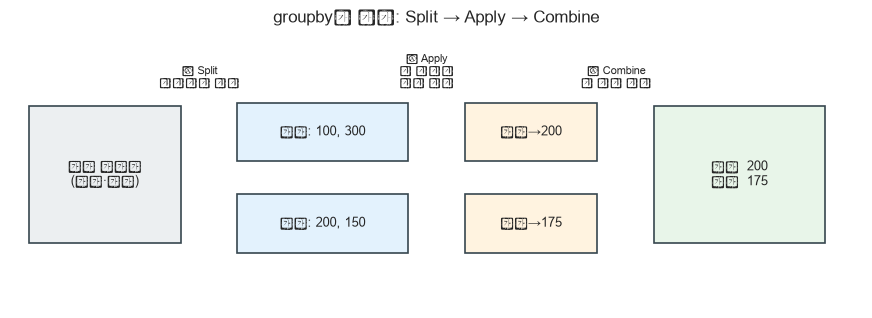

In [62]:
# ─────────────────────────────────────────────
# [도식] split-apply-combine 흐름
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis("off")

def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#37474f", lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)

# 원본
box(0.02, 0.30, 0.16, 0.42, "원본 데이터\n(지역·금액)", "#eceff1")
ax.annotate("", xy=(0.22, 0.5), xytext=(0.18, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.20, 0.78, "① Split\n기준열로 쪼갬", ha="center", fontsize=8)

# 그룹들
box(0.24, 0.55, 0.18, 0.18, "서울: 100, 300", "#e3f2fd")
box(0.24, 0.27, 0.18, 0.18, "부산: 200, 150", "#e3f2fd")
ax.annotate("", xy=(0.46, 0.5), xytext=(0.42, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.44, 0.78, "② Apply\n각 그룹에\n평균 적용", ha="center", fontsize=8)

# 적용 결과
box(0.48, 0.55, 0.14, 0.18, "서울→200", "#fff3e0")
box(0.48, 0.27, 0.14, 0.18, "부산→175", "#fff3e0")
ax.annotate("", xy=(0.66, 0.5), xytext=(0.62, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.64, 0.78, "③ Combine\n한 표로 모음", ha="center", fontsize=8)

# 최종
box(0.68, 0.30, 0.18, 0.42, "서울  200\n부산  175", "#e8f5e9")

ax.set_xlim(0, 0.9); ax.set_ylim(0.1, 0.95)
plt.title("groupby의 동작: Split → Apply → Combine", fontsize=12)
plt.show()

In [63]:
# 분석용 통합 표를 안전하게 다시 만듭니다 (validate로 관계 확인).
full = (
    orders
    .merge(customers, on="customer_id", how="left", validate="m:1")
    .merge(products, on="product_id", how="left", validate="m:1")
)
print("통합 표 full:", full.shape)

# 예제 1) 지역별 평균 주문 금액 — 한 열, 한 함수
region_mean = full.groupby("region")["amount"].mean().round(0)
print("\n[지역별 평균 주문 금액]")
print(region_mean)

통합 표 full: (2000, 13)

[지역별 평균 주문 금액]
region
경기    78616.0
대구    76316.0
부산    80983.0
서울    80417.0
인천    83677.0
Name: amount, dtype: float64


In [64]:
# 예제 2) 여러 통계를 한 번에 + 컬럼 이름 지정 (named aggregation)
# 카테고리별로 매출 합계·평균 금액·주문 건수를 한 표로.
category_summary = (
    full.groupby("category")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count"),
        평균수량=("quantity", "mean"),
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
print("[카테고리별 요약 — 매출 내림차순]")
display(category_summary)

[카테고리별 요약 — 매출 내림차순]


,매출합계,평균금액,주문건수,평균수량
category,,,,
식품,55973400.0,109537.0,511,1.7
뷰티,34568800.0,80020.4,432,1.6
패션,28351600.0,68814.6,412,1.7
도서,21984300.0,54282.2,405,1.6
가전,18920900.0,78837.1,240,1.6


In [65]:
# 예제 3) 두 기준으로 그룹 나누기 — 지역 × 회원등급 교차 평균 금액
region_member = (
    full.groupby(["region", "membership"])["amount"]
    .mean().round(0)
    .unstack()   # membership을 열로 펼쳐 보기 좋게 (Part 6에서 자세히)
)
print("[지역 × 회원등급 평균 주문 금액]")
display(region_member)

[지역 × 회원등급 평균 주문 금액]


membership,basic,premium,vip
region,,,
경기,80622.0,76234.0,75059.0
대구,74169.0,85365.0,60374.0
부산,80731.0,84822.0,70329.0
서울,85657.0,65652.0,78330.0
인천,76956.0,89606.0,88488.0


## transform — 그룹 통계를 원래 행에 되돌려주기

# 5. transform — 그룹 통계를 원래 행에 되돌려주기

`agg`는 그룹을 **한 줄로 접습니다.** 카테고리 5개 → 5행 요약표가 되죠. 그런데 이런 질문은 어떨까요?

> "각 주문 금액이, **그 주문이 속한 카테고리의 평균보다** 큰가 작은가?"

이걸 계산하려면 **각 주문 행(2000개)** 옆에 "그 카테고리의 평균"을 붙여야 합니다. 즉 그룹 통계를 내되, **행 수를 줄이지 않고** 원래 길이 그대로 돌려받아야 하죠. 이것이 `transform`입니다.

> ❓ **이 파트에서 답할 질문:** 그룹별 통계를, 행을 줄이지 않고 각 행 옆에 그대로 붙이려면?

## 💡 쉽게 말하면 — agg는 '접고', transform은 '펼친다'

```text
원본 (카테고리, 금액)        agg  → 그룹당 한 줄 (접힘, 5행)
 패션  100                    패션  평균 200
 뷰티  300         ──►        뷰티  평균 150
 패션  300                    ...
 ...

                  transform → 원본 길이 그대로 (펼침, 2000행)
                   패션  100  | 그룹평균 200
                   뷰티  300  | 그룹평균 150
                   패션  300  | 그룹평균 200   ← 같은 그룹은 같은 값이 채워짐
```

`agg`는 그룹을 대표값 하나로 줄이고, `transform`은 그 대표값을 **그룹 안 모든 행에 다시 뿌려줍니다.** 그래서 결과 길이가 원본과 같죠.

## 자세히 알아보기 — agg vs transform

| | `agg` | `transform` |
| --- | --- | --- |
| 결과 행 수 | 그룹 수만큼 (줄어듦) | **원본과 동일** (안 줄어듦) |
| 주 용도 | 요약표 만들기 | 원본에 그룹 통계 **컬럼 추가** |
| 대표 활용 | 보고서·대시보드 | 그룹 내 비중·편차·정규화 |

`transform`의 단골 활용 두 가지:
- **그룹 내 비중:** 각 행 / 그룹 합계 → "이 주문은 그 카테고리 매출의 몇 %인가"
- **그룹 내 편차:** 각 행 - 그룹 평균 → "이 주문은 그 카테고리 평균보다 얼마나 큰가"

## 데이터로 확인해 봅시다

> **읽는 법:** `category_avg` 열을 보면, **같은 카테고리 행은 모두 같은 평균값**이 채워져 있습니다. `transform("mean")`이 그룹 평균을 그룹 안 모든 행에 뿌려준 것이죠. `diff_from_avg`가 양수면 "그 주문은 카테고리 평균보다 큰 주문"입니다. `agg`였다면 5행으로 접혀서 이런 행 단위 비교가 불가능했을 겁니다.

> **읽는 법:** `transform("sum")`으로 각 행 옆에 "그 카테고리 전체 매출"을 붙인 뒤, `amount`를 그 값으로 나누면 **그룹 내 점유율**이 나옵니다. 한 카테고리의 점유율을 다 더하면 100%가 되죠(검산). 이런 정규화는 `agg`로는 못 합니다 — 분모(그룹 합)를 각 행에 되돌려줘야 하니 반드시 `transform`입니다.

> 💡 **개념 연결:** Part 4의 `agg`와 Part 5의 `transform`은 둘 다 `groupby` 위에서 동작하지만 **방향이 반대**입니다. `agg`는 그룹을 줄여 **요약표**를 만들고(분석 결과), `transform`은 그룹 통계를 펼쳐 **원본에 특성을 추가**합니다(분석 재료). 머신러닝의 피처 엔지니어링(feature engineering)에서 transform이 특히 자주 쓰입니다.

> 📌 **다른 산업에서는?** `transform`은 금융에서 "이 거래액이 해당 계좌 평균 대비 얼마나 이상한가"(이상거래 탐지), 마케팅에서 "이 사용자의 클릭률이 같은 세그먼트 평균 대비 어떤가", 제조에서 "이 측정값이 같은 라인 평균에서 얼마나 벗어났나"를 계산할 때 똑같이 쓰입니다.

### 스스로 해보자! ✏️ (5)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`transform`을 써서, 각 주문 옆에 **"그 고객(`customer_id`)의 평균 주문 금액"** 을 `customer_avg`라는 새 컬럼으로 붙여보세요. 그리고 자기 평균보다 큰 주문이 몇 건인지 세어보세요.

<details>
<summary>💡 힌트 (클릭)</summary>

```python
full["customer_avg"] = full.groupby("customer_id")["amount"].transform("mean").round(0)

bigger = (full["amount"] > full["customer_avg"]).sum()
print(f"자기 평균보다 큰 주문: {bigger}건 / 전체 {len(full)}건")
display(full[["customer_id", "amount", "customer_avg"]].head())
```

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. `agg`와 `transform`의 **결과 행 수**는 각각 어떻게 다른가요?
agg는 그룹 수, transform은 원본과 동일한 행 수.

2. "그룹 내 점유율"은 왜 `agg`가 아니라 `transform`으로 계산해야 할까요?
분모(그룹 합)를 각 행에 <되돌려줘야 하니> 반드시 transform입니다.

3. 원본 표에 "그룹 평균" 컬럼을 추가하고 싶다면 둘 중 무엇을 쓸까요?
transform. 왜냐하면 원본에 특성을 추가하는 것이기 때문에.

> 💡 **다음 Part 예고:** 지금까지 만든 요약표들(지역별, 카테고리별…)은 대부분 **세로로 긴 형태**였습니다. 그런데 경영진은 "행은 지역, 열은 카테고리"인 **교차표**를 더 좋아하죠. 표의 모양 자체를 바꾸는 `pivot_table`과 wide/long 변환을 다음에 배웁니다.

In [71]:
# 예제 1) 각 주문에 '그 카테고리의 평균 금액'을 컬럼으로 붙이기
full["category_avg"] = full.groupby("category")["amount"].transform("mean").round(0)

# '그 주문이 카테고리 평균보다 큰가' (편차) 컬럼도 추가
full["diff_from_avg"] = (full["amount"] - full["category_avg"]).round(0)

print("transform은 행을 줄이지 않습니다. full 행 수:", len(full), "(여전히 2000)")
display(full[["order_id", "category", "amount", "category_avg", "diff_from_avg"]].head(6))

transform은 행을 줄이지 않습니다. full 행 수: 2000 (여전히 2000)


,order_id,category,amount,category_avg,diff_from_avg
0,O00001,패션,19900.0,68815.0,-48915.0
1,O00002,식품,89900.0,109537.0,-19637.0
2,O00003,식품,49900.0,109537.0,-59637.0
3,O00004,뷰티,89900.0,80020.0,9880.0
4,O00005,뷰티,149700.0,80020.0,69680.0
5,O00006,패션,129900.0,68815.0,61085.0


In [72]:
# 예제 2) 그룹 내 '비중(점유율)' 계산 — 각 주문이 그 카테고리 매출에서 차지하는 비율
cat_total = full.groupby("category")["amount"].transform("sum")
full["share_in_category"] = (full["amount"] / cat_total * 100).round(3)

print("각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):")
display(full[["order_id", "category", "amount", "share_in_category"]].head(6))

# 검산: 한 카테고리의 share를 모두 더하면 100%가 되어야 합니다.
check = full[full["category"] == "패션"]["share_in_category"].sum()
print(f"\n검산 — '패션' 카테고리 비중 합계: {check:.1f}%  (100%면 정상)")

각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):


,order_id,category,amount,share_in_category
0,O00001,패션,19900.0,0.070
1,O00002,식품,89900.0,0.161
2,O00003,식품,49900.0,0.089
3,O00004,뷰티,89900.0,0.260
4,O00005,뷰티,149700.0,0.433
5,O00006,패션,129900.0,0.458



검산 — '패션' 카테고리 비중 합계: 100.0%  (100%면 정상)


In [73]:
# 스스로 해보자! (5)
# customer_id로 그룹지어 amount의 평균을 transform으로 각 행에 붙여 보세요.
full["customer_avg"] = full.groupby("customer_id")["amount"].transform("mean")

# 자기 고객 평균보다 큰 주문(amount > customer_avg)이 몇 건인지 세어 보세요.
bigger = (full["amount"] > full["customer_avg"]).sum()
print(f"자기 평균보다 큰 주문: {bigger}건 / 전체 {len(full)}건")
display(full[["customer_id", "amount", "customer_avg"]].head())

자기 평균보다 큰 주문: 755건 / 전체 2000건


,customer_id,amount,customer_avg
0,C0040,19900.0,61533.333333
1,C0224,89900.0,92100.000000
2,C0115,49900.0,76433.333333
3,C0186,89900.0,124114.285714
4,C0056,149700.0,74750.000000


## pivot_table & wide/long — 표의 모양을 바꾸기

# 6. pivot_table & wide/long — 표의 모양을 바꾸기

`groupby(["region","category"])["amount"].sum()`을 하면 결과가 **세로로 길게** 나옵니다(지역×카테고리 = 25행). 그런데 보고서에 넣을 땐 **"행=지역, 열=카테고리"인 교차표**가 훨씬 읽기 좋죠. 같은 데이터라도 **모양(format)** 을 바꾸면 전달력이 달라집니다.

표의 모양에는 크게 두 가지가 있습니다: **long(긴 형태)** 와 **wide(넓은 형태)**.

> ❓ **이 파트에서 답할 질문:** 같은 데이터를, 목적에 맞는 표 모양(교차표/긴 표)으로 어떻게 바꿀까요?

## 💡 쉽게 말하면 — long vs wide

```text
[long: 긴 형태]              [wide: 넓은 형태]
 지역  카테고리  매출           지역   패션   뷰티   식품
 서울  패션     100            서울   100    200    50
 서울  뷰티     200    ◄──►    부산   300    150    80
 서울  식품     50
 부산  패션     300            (카테고리가 '열'로 펼쳐짐)
 ...
 (한 행 = 한 조합)
```

- **long:** 한 행이 하나의 관측/조합. 데이터 저장·집계에 유리. (`groupby` 결과의 기본 모양)
- **wide:** 한 축을 열로 펼침. 사람이 보고 비교하기 좋음. (보고서·엑셀 표)

`pivot_table`은 long → wide로, `melt`는 wide → long으로 바꿉니다. `stack`/`unstack`은 인덱스를 접고 펴서 같은 일을 합니다.

## 자세히 알아보기

| 도구 | 방향 | 핵심 인자 |
| --- | --- | --- |
| `pivot_table` | long → wide | `index`(행), `columns`(열), `values`(값), `aggfunc`(집계함수) |
| `melt` | wide → long | `id_vars`(고정 열), `value_vars`(녹일 열) |
| `unstack` | 인덱스 → 열 | 멀티인덱스의 한 레벨을 열로 |
| `stack` | 열 → 인덱스 | `unstack`의 반대 |

> 💡 **개념 연결:** `pivot_table`은 사실 **`groupby` + `unstack`을 한 번에** 해주는 도구입니다. Part 4에서 `groupby([...]).mean().unstack()`을 했던 걸 떠올려보세요. `pivot_table`은 그 과정을 한 함수로 묶은 것입니다.

## 데이터로 확인해 봅시다

> **읽는 법:** 왼쪽 long과 오른쪽 wide는 **완전히 같은 데이터**입니다. 모양만 다르죠. `pivot_table`은 왼쪽을 오른쪽으로, `melt`는 오른쪽을 왼쪽으로 바꿉니다.

실제 데이터로 교차표를 만들어봅시다.

> **읽는 법:**
> - `pivot_table`의 `margins=True`는 마지막에 행·열 **합계(All)** 를 붙여줍니다. 보고서용으로 편리하죠.
> - `fill_value=0`은 그 조합의 데이터가 없어 생긴 빈칸을 0으로 채웁니다(예: 특정 월에 안 팔린 카테고리).
> - `melt`는 wide를 다시 long으로 되돌립니다. seaborn 같은 시각화 도구나 DB 저장은 보통 long 형태를 선호하므로, **"보여줄 땐 wide, 저장·그릴 땐 long"** 으로 기억하세요.

> 📌 **다른 산업에서는?** `pivot_table`은 마케팅에서 "캠페인 × 채널 전환율" 교차표, 헬스케어에서 "진료과 × 월별 환자 수", 제조에서 "라인 × 불량유형" 집계표를 만들 때 똑같이 쓰입니다. 엑셀의 피벗테이블과 정확히 같은 개념입니다.

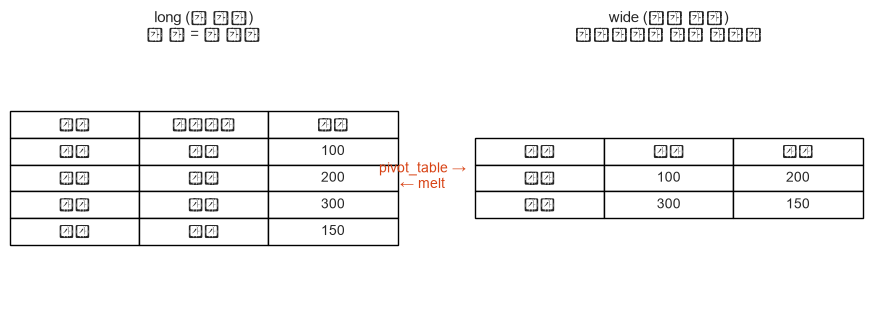

In [74]:
# ─────────────────────────────────────────────
# [도식] long ↔ wide 변환
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

long_demo = [["서울", "패션", 100], ["서울", "뷰티", 200],
             ["부산", "패션", 300], ["부산", "뷰티", 150]]
axes[0].axis("off")
axes[0].set_title("long (긴 형태)\n한 행 = 한 조합", fontsize=11)
tbl0 = axes[0].table(cellText=long_demo, colLabels=["지역", "카테고리", "매출"],
                     loc="center", cellLoc="center")
tbl0.scale(1, 1.6)

wide_demo = [["서울", 100, 200], ["부산", 300, 150]]
axes[1].axis("off")
axes[1].set_title("wide (넓은 형태)\n카테고리가 열로 펼쳐짐", fontsize=11)
tbl1 = axes[1].table(cellText=wide_demo, colLabels=["지역", "패션", "뷰티"],
                     loc="center", cellLoc="center")
tbl1.scale(1, 1.6)

fig.text(0.5, 0.5, "pivot_table →\n← melt", ha="center", va="center", fontsize=10, color="#d84315")
plt.show()

In [75]:
# 예제 2) 시간 축 피벗 — 월별 × 카테고리 매출 (실무에서 가장 흔한 형태)
full["month"] = full["order_date"].dt.to_period("M").astype(str)   # 'YYYY-MM'

month_cat = pd.pivot_table(
    full, index="month", columns="category", values="amount",
    aggfunc="sum", fill_value=0,   # 빈 칸은 0으로
).round(0)
print("[월별 × 카테고리 매출]")
display(month_cat)

[월별 × 카테고리 매출]


category,가전,도서,뷰티,식품,패션
month,,,,,
2025-01,4789500.0,6519100.0,9231500.0,14877000.0,6662400.0
2025-02,4201800.0,6364500.0,7723400.0,9683200.0,5754700.0
2025-03,4919900.0,5053900.0,8431900.0,16556800.0,8212000.0
2025-04,5009700.0,4046800.0,9182000.0,14856400.0,7722500.0


In [76]:
# 예제 3) melt — wide를 다시 long으로 (그래프나 저장에 유리한 형태)
month_cat_reset = month_cat.reset_index()
long_form = month_cat_reset.melt(
    id_vars="month",          # 고정할 열
    var_name="category",      # 펼쳐졌던 열 이름이 들어갈 새 컬럼
    value_name="amount",      # 값이 들어갈 새 컬럼
)
print("wide → long 복원 (앞 6행):")
display(long_form.head(6))

# stack/unstack도 같은 일을 합니다: unstack은 wide로 펼치고, stack은 long으로 접습니다.
print("\nstack()으로 다시 접기 (long 형태, 앞부분):")
print(month_cat.stack().head(4))

wide → long 복원 (앞 6행):


,month,category,amount
0,2025-01,가전,4789500.0
1,2025-02,가전,4201800.0
2,2025-03,가전,4919900.0
3,2025-04,가전,5009700.0
4,2025-01,도서,6519100.0
5,2025-02,도서,6364500.0



stack()으로 다시 접기 (long 형태, 앞부분):
month    category
2025-01  가전           4789500.0
         도서           6519100.0
         뷰티           9231500.0
         식품          14877000.0
dtype: float64


### 스스로 해보자! ✏️ (6)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`pivot_table`로 **행=회원등급(`membership`), 열=지역(`region`), 값=평균 주문 금액(`amount`의 mean)** 인 교차표를 만들어보세요. 빈 칸은 0으로 채우고, 소수점은 반올림하세요.

In [78]:
# 스스로 해보자! (6)

member_region = pd.pivot_table(full, index="membership", columns="region", 
values="amount", aggfunc="mean").round(0)

print("[회원 등급 × 지역 매출]")
display(member_region)

[회원 등급 × 지역 매출]


region,경기,대구,부산,서울,인천
membership,,,,,
basic,80622.0,74169.0,80731.0,85657.0,76956.0
premium,76234.0,85365.0,84822.0,65652.0,89606.0
vip,75059.0,60374.0,70329.0,78330.0,88488.0


<details>
<summary>💡 힌트 (클릭)</summary>

```python
member_region = pd.pivot_table(
    full, index="membership", columns="region",
    values="amount", aggfunc="mean", fill_value=0,
).round(0)
display(member_region)
```

등급(행)과 지역(열)이 만나는 칸에서 "어느 지역의 어떤 등급 고객이 가장 많이 쓰는가"를 한눈에 볼 수 있습니다.

</details>

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. long 형태와 wide 형태는 각각 어떤 상황에 유리한가요?
 long은 데이터 분석에서, wide는 사람이 비교하며 볼 때 유리

2. `pivot_table`의 `index`·`columns`·`values`·`aggfunc`은 각각 무엇을 정하나요?
index는 행, columns는 열, values는 값, aggfuncs는 값에 적용할 함수(집계함수)

3. wide를 다시 long으로 되돌리는 함수는 무엇인가요?
 melt

> 💡 **다음 Part 예고:** 이제 병합·집계·피벗을 모두 배웠습니다. 종합 실습에서 이 셋을 **하나의 파이프라인**으로 묶어, 실제 경영 보고서에 들어갈 **월별 KPI 요약표**를 완성해봅시다.

# 🧪 종합 실습 — 세 테이블을 합쳐 월별 KPI 요약표 만들기

지금까지 배운 것을 **하나의 파이프라인**으로 묶을 차례입니다. 미션은 동료가 처음에 부탁한 그것입니다.

> "세 테이블을 합쳐서, **월별 핵심 지표(KPI)** 를 한 장으로 정리해주세요. 경영 회의에 올릴 거예요."

아래 순서로 진행합니다. **이 종합 실습은 단독 실행되도록** 데이터를 새 스냅샷으로 다시 만듭니다(앞에서 만든 변수에 의존하지 않습니다).

```text
시나리오 1) 키 검증 후 3-테이블 병합   (Part 2~3)
시나리오 2) groupby + agg로 월별 KPI   (Part 4)
시나리오 3) pivot_table + transform     (Part 5~6)
마무리)     비즈니스 보고서 양식으로 정리
```

## 시나리오 1 — 키 검증 후 3-테이블 병합

합치기 **전에** 검증부터 합니다(오늘의 핵심 태도). 그다음 안전하게 `validate`를 걸어 병합합니다.

> **읽는 법:** 검증 4종이 모두 0건 → 키가 깨끗합니다. `validate="m:1"`이 에러 없이 통과했고, 병합 후 행 수가 원본 주문 수(1500)와 같으니 **행 폭증도 없습니다.** 이제 이 `df`를 믿고 집계해도 됩니다.

## 시나리오 2 — 월별 KPI 요약표 (groupby + agg)

경영진이 보는 핵심 지표(KPI)를 **월별로** 집계합니다: 총매출, 주문 건수, 객단가(주문당 평균 금액), 구매 고객 수.

> **읽는 법:** `nunique`는 "고유 개수"를 셉니다 — 주문 건수가 아니라 **서로 다른 고객이 몇 명**인지를 알려주죠. `pct_change()`는 바로 위 행(전월) 대비 변화율입니다. 첫 달은 비교 대상이 없어 `NaN`입니다(정상). 이 표 하나로 "매출이 늘었나, 손님이 늘어서인가 객단가가 올라서인가"를 읽을 수 있습니다.

## 시나리오 3 — 교차표(pivot) + 점유율(transform)

월 × 카테고리 매출 교차표를 만들고, 각 주문이 그 달 매출에서 차지하는 비중도 계산합니다.

> **읽는 법:** 교차표는 "어느 달에 어떤 카테고리가 강했나"를 한눈에 보여줍니다. `transform`으로 만든 점유율은 개별 주문 수준의 기여도를 알려주죠. 같은 데이터를 **그룹 요약(pivot)** 과 **행 단위 특성(transform)** 두 방향으로 본 것입니다.

## 📊 비즈니스 보고서로 정리하기

마지막으로, 위 결과를 **경영 회의에 올릴 보고서 양식**으로 묶습니다. 분석가의 진짜 일은 표를 만드는 것이 아니라 **표에서 읽어낸 의사결정 근거**를 전달하는 것입니다.

> 📝 **데이터 분석 보고서 (양식 예시)**
>
> **1. 분석 개요**
> - 대상: 모두마켓 주문 1,500건 (2025-01 ~ 2025-05), 고객·상품 정보 병합
> - 방법: 3개 테이블 키 검증 후 `m:1` 병합 → 월별 KPI 집계 → 교차표·점유율 분석
>
> **2. 핵심 발견 (위 셀에서 추출한 숫자로 채우세요)**
> - 매출이 가장 높았던 달은 **{best_month}** 였으며, 전월 대비 증감률은 `매출증감률(%)` 열에서 확인.
> - 카테고리 중 **{top_category}**, 지역 중 **{top_region}** 의 매출 기여가 가장 컸음.
> - 전체 객단가는 약 **{overall_aov}원**.
>
> **3. 데이터 신뢰성 (반드시 기록)**
> - 병합 전 키 검증: 중복 0건, 미매칭 0건 → 행 폭증·조용한 결측 없음.
> - `validate="m:1"` 통과 → 관계 가정(주문:상품 = m:1) 유효.
>
> **4. 제언**
> - 월별 매출 변동의 원인(고객 수 ↑ vs 객단가 ↑)을 `구매고객수`·`객단가` 열로 분해해 마케팅 전략 차별화.
>
> 💡 위 `{...}` 칸을 마무리 셀의 출력 숫자로 채우면 보고서 초안이 완성됩니다. **"왜 이 결론인가"의 근거(어떤 표·어떤 검증)를 반드시 함께 적으세요** — 이것이 오늘의 핵심 태도입니다.

# ✅ 오늘의 퀴즈

배운 내용을 잠깐 확인해볼게요. 틀려도 괜찮습니다.

### 개념 퀴즈

1. 컬럼 구조가 **같은** 두 표를 위아래로 이어 붙일 때 쓰는 함수는? (`concat')


2. `merge`에서 "왼쪽 표는 전부 남기고, 오른쪽은 짝이 맞는 것만 붙인다"는 `how` 값은? (`left`)


3. 오른쪽 표에 같은 키가 여러 번 있을 때 병합하면 생기는 현상의 이름은? 이를 합치는 순간 에러로 막아주는 인자는? validate="m:1"


4. `agg`와 `transform` 중, 결과 행 수가 **원본과 동일하게** 유지되는 것은? transform


5. long 형태를 "행=A, 열=B"인 교차표(wide)로 바꾸는 함수는? pivot_table

### 코드 퀴즈

`full`(또는 종합 실습의 `df`)에서, **회원등급별 평균 주문 금액**을 구해 가장 높은 등급을 출력하세요. 모범 답안을 바로 아래에 둡니다.



In [81]:
# 코드 퀴즈 — 모범 답안
# 회원등급별 평균 주문 금액 → 가장 높은 등급 찾기
ans = df.groupby("membership")["amount"].mean().round(0).sort_values(ascending=False)
print("회원등급별 평균 주문 금액:")
print(ans)
print(f"\n→ 평균 주문 금액이 가장 높은 등급: '{ans.idxmax()}' ({ans.max():,.0f}원)")

회원등급별 평균 주문 금액:
membership
vip        67268.0
premium    61090.0
basic      59518.0
Name: amount, dtype: float64

→ 평균 주문 금액이 가장 높은 등급: 'vip' (67,268원)


> **읽는 법:** `groupby("membership")["amount"].mean()`으로 등급별 평균을 내고, `sort_values`로 정렬한 뒤 `idxmax()`로 1위 등급의 이름을 꺼냈습니다. 오늘 배운 `groupby + agg`의 가장 기본적인 활용입니다.

# 🎓 정리 & 다음 시간 예고

## 오늘 배운 것 — 개념 연결 도식

오늘은 **흩어진 표를 하나로 모아 인사이트로 바꾸는** 전 과정을 배웠습니다.

```text
[Part 1] concat        같은 모양 조각을 이어 붙이기 (행/열)
   ↓  "모양이 다르면?"
[Part 2] merge          공통 키로 짝지어 연결 (inner/left/right/outer)
   ↓  "키에 문제가 있으면?"
[Part 3] 키 검증         중복·미매칭 확인 → validate / indicator (행 폭증·조용한 결측 방지)
   ↓  "이제 그룹별로 요약"
[Part 4] groupby + agg  쪼개고-적용하고-합치기 → 요약표 (행 줄어듦)
   ↓  "요약값을 행마다 붙이려면?"
[Part 5] transform      그룹 통계를 원본 길이로 되돌림 (비중·편차)
   ↓  "표 모양을 바꾸려면?"
[Part 6] pivot_table    long ↔ wide 변환 → 교차표
   ↓
[종합 실습] 검증 → 병합 → 월별 KPI → 교차표·보고서
```

## 한 장 정리 표

| 도구 | 한마디로 | 핵심 포인트 |
| --- | --- | --- |
| `concat` | 이어 붙이기 | 같은 모양 전제. `axis`로 방향, `ignore_index` |
| `merge` | 키로 연결 | `how`(inner/left/right/outer)가 결과를 좌우 |
| 키 검증 | 합치기 전 점검 | 중복·미매칭 확인, `validate`, `indicator` |
| `groupby`+`agg` | 그룹 요약 | split-apply-combine, named aggregation |
| `transform` | 그룹 통계 되돌리기 | 행 안 줄임, 비중·편차 계산 |
| `pivot_table` | 모양 바꾸기 | long↔wide, 교차표, `margins` |

## 진단 → 다음 행동 매핑

| 데이터 상황 | 자연스러운 다음 행동 |
| --- | --- |
| 같은 양식의 파일이 여러 개 | `concat`으로 이어 붙이기 |
| 정보가 여러 표에 흩어짐 | 키 검증 → `merge` |
| 병합 후 행이 불어남 | 키 중복 확인 → `validate="m:1"` |
| 그룹별 요약이 필요 | `groupby` + `agg` |
| 그룹 통계를 원본에 붙이고 싶음 | `transform` |
| 보고용 교차표가 필요 | `pivot_table` |

## 🎓 다음 시간 예고 — D+005 문자열·날짜 다루기

오늘 우리는 표를 **합쳤습니다.** 그런데 합친 표 안에는 아직 **쓰기 어려운 형태**의 값들이 남아 있습니다. 처음 데이터를 받았을 때 `order_date`가 `2025-01-01`, `2025/01/01`, `20250101`처럼 **제각각인 문자열**이었던 것을 기억하시나요? 오늘은 편의를 위해 깔끔한 날짜로 두고 시작했지만, 현실에서는 그 정제가 먼저 필요합니다.

> **다음 시간:** 합쳐진 데이터 안의 **문자열과 날짜를 쓸 수 있는 형태로** 만듭니다. 공백·대소문자·특수문자를 정리하고(`str` accessor·정규표현식), 제각각인 날짜를 통일해 파싱하고(`dt` accessor·`resample`), 로그 데이터에서 원하는 정보를 뽑아냅니다.

# 📝 오늘의 과제

> **노트북 안은 짧은 점검, 본격 적용은 노트북 밖 과제로.** 오늘 배운 병합·집계·피벗을 여러분의 손으로 처음부터 끝까지 적용해봅니다.

## 미션: 모두마켓 "분기 성과 요약 보고서" 만들기

아래 단계를 따라 하나의 분석 노트북을 완성하고 GitHub에 제출하세요.

1. **데이터 준비:** 이 노트북의 종합 실습 데이터 생성 셀(`np.random.seed(7)` 셀)을 그대로 가져와 `orders`·`customers`·`products`를 만드세요.
2. **키 검증 (필수):** 병합 전 세 검증(중복·미매칭·관계)을 수행하고, 결과를 마크다운으로 **기록**하세요. ("검증 결과 ___ 이므로 m:1 병합이 안전하다.")
3. **병합:** `validate`를 걸어 세 테이블을 하나로 합치세요.
4. **집계:** 다음 두 요약표를 만드세요.
   - 지역 × 회원등급 매출 교차표 (`pivot_table`)
   - 카테고리별 KPI(매출·건수·객단가) 요약표 (`groupby` + `agg`)
5. **특성 추가:** `transform`으로 "각 주문이 그 지역 매출에서 차지하는 비중" 컬럼을 추가하세요.
6. **보고서:** 종합 실습의 보고서 양식을 채워, 발견 3가지 + 제언 1가지를 작성하세요.

## 제출 방법 (GitHub)

- 개인 포트폴리오 repo의 `D004/` 폴더에 `D004_병합집계_보고서.ipynb`로 저장합니다.
- **1주차에는** `main`에 바로 push해도 괜찮습니다. (2주차부터 작업 브랜치 → PR 흐름으로 전환합니다.)
- 노트북은 **처음부터 끝까지 순서대로 실행해 오류가 없어야** 합니다.

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 병합·집계가 의도대로 동작하고 행 폭증·결측 사고가 없는가 |
| 합리성 | 키 검증을 수행하고 `how`·`validate` 선택의 근거를 기록했는가 |
| 인사이트 | 요약표에서 의미 있는 발견과 제언을 끌어냈는가 |

> 🚀 **더 나아가기:** 종합 실습 데이터의 `seed`를 바꾸거나, 여러분이 관심 있는 다른 도메인(카페 판매, 도서 대출 등)의 가상 데이터를 만들어 같은 분석을 적용해보세요. 정해진 정답은 없습니다.

수고하셨습니다! 🎉

오늘 여러분은 흩어진 세 테이블을 **안전하게 합치고**, **그룹별로 요약하고**, **보기 좋은 표로 바꾸는** 데이터 랭글링의 핵심 기술을 익혔습니다. 무엇보다 "합치기 전에 키부터 검증한다"는 분석가의 습관을 손에 넣었죠. 다음 시간에는 합쳐진 데이터 안의 문자열과 날짜를 길들여 봅시다.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 교안은 생성형 AI를 활용해 제작하고 제작자가 검수했습니다.<br>
무단 복제 및 배포를 금합니다.</sub>

In [79]:
# ─────────────────────────────────────────────
# 종합 실습용 데이터 — 새 스냅샷 (이 셀부터 단독 실행 가능)
# ─────────────────────────────────────────────
np.random.seed(7)

n_cust = 200
cust = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_cust + 1)],
    "region": np.random.choice(["서울", "경기", "부산", "인천"], n_cust),
    "membership": np.random.choice(["basic", "premium", "vip"], n_cust, p=[0.6, 0.3, 0.1]),
})

cats = ["패션", "뷰티", "식품", "가전"]
n_prod = 30
prod = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_prod + 1)],
    "category": np.random.choice(cats, n_prod),
    "price": np.random.choice([12000, 25000, 40000, 75000], n_prod),
})

n_ord = 1500
oc = np.random.choice(cust["customer_id"], n_ord)
op = np.random.choice(prod["product_id"], n_ord)
qty = np.random.choice([1, 1, 2, 3], n_ord)
amt = prod.set_index("product_id")["price"].loc[op].values * qty
odate = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 150, n_ord), unit="D")
ordr = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_ord + 1)],
    "customer_id": oc, "product_id": op,
    "quantity": qty, "amount": amt.astype(float), "order_date": odate,
})
print("스냅샷 준비 완료 — orders:", ordr.shape, "| customers:", cust.shape, "| products:", prod.shape)

스냅샷 준비 완료 — orders: (1500, 6) | customers: (200, 3) | products: (30, 3)


In [80]:
# 시나리오 1 — 검증 → 병합
# (1) 검증: 룩업 표의 키가 유일한가, 주문의 키가 모두 매칭되는가
print("[병합 전 검증]")
print("  customers 키 중복:", cust["customer_id"].duplicated().sum(), "건")
print("  products  키 중복:", prod["product_id"].duplicated().sum(), "건")
print("  매칭 안 되는 customer_id:", (~ordr["customer_id"].isin(cust["customer_id"])).sum(), "건")
print("  매칭 안 되는 product_id :", (~ordr["product_id"].isin(prod["product_id"])).sum(), "건")

# (2) 병합: validate로 관계 가정(m:1)을 강제. indicator로 매칭 확인.
df = (
    ordr
    .merge(cust, on="customer_id", how="left", validate="m:1")
    .merge(prod, on="product_id", how="left", validate="m:1")
)
print("\n[병합 결과] 행 수:", len(df), "(원본 주문 수와 같으면 폭증 없음)")
display(df.head(3))

[병합 전 검증]
  customers 키 중복: 0 건
  products  키 중복: 0 건
  매칭 안 되는 customer_id: 0 건
  매칭 안 되는 product_id : 0 건

[병합 결과] 행 수: 1500 (원본 주문 수와 같으면 폭증 없음)


,order_id,customer_id,product_id,quantity,amount,order_date,region,membership,category,price
0,O00001,C0032,P005,3,120000.0,2025-04-12,서울,premium,패션,40000
1,O00002,C0049,P020,1,25000.0,2025-03-09,서울,basic,식품,25000
2,O00003,C0041,P016,3,36000.0,2025-01-27,인천,basic,패션,12000


In [ ]:
# 시나리오 2 — 월별 KPI
df["month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_kpi = (
    df.groupby("month")
    .agg(
        총매출=("amount", "sum"),
        주문건수=("order_id", "count"),
        객단가=("amount", "mean"),
        구매고객수=("customer_id", "nunique"),   # nunique: 고유 고객 수
    )
    .round(0)
)
# 전월 대비 매출 증감률(%)도 추가 — 경영 보고서의 단골 지표
monthly_kpi["매출증감률(%)"] = (monthly_kpi["총매출"].pct_change() * 100).round(1)

print("[월별 KPI 요약표]")
display(monthly_kpi)

In [ ]:
# 시나리오 3-1 — 월 × 카테고리 매출 교차표 (pivot_table)
month_category = pd.pivot_table(
    df, index="month", columns="category", values="amount",
    aggfunc="sum", fill_value=0, margins=True, margins_name="합계",
).round(0)
print("[월 × 카테고리 매출 교차표]")
display(month_category)

# 시나리오 3-2 — 각 주문이 '그 달 전체 매출'에서 차지하는 비중 (transform)
df["month_total"] = df.groupby("month")["amount"].transform("sum")
df["share_in_month(%)"] = (df["amount"] / df["month_total"] * 100).round(3)
print("\n[주문별 월 매출 점유율 — 앞 5행]")
display(df[["order_id", "month", "amount", "share_in_month(%)"]].head())

In [ ]:
# 핵심 숫자 자동 추출 (보고서 문장에 채워 넣기 위함)
best_month = monthly_kpi["총매출"].idxmax()
best_month_sales = monthly_kpi["총매출"].max()
top_category = df.groupby("category")["amount"].sum().idxmax()
top_region = df.groupby("region")["amount"].sum().idxmax()
overall_aov = df["amount"].mean()

print("자동 추출된 핵심 숫자")
print(f"  최대 매출 월   : {best_month} ({best_month_sales:,.0f}원)")
print(f"  최대 매출 카테고리: {top_category}")
print(f"  최대 매출 지역 : {top_region}")
print(f"  전체 객단가    : {overall_aov:,.0f}원")

In [ ]:
# 코드 퀴즈 — 모범 답안
# 회원등급별 평균 주문 금액 → 가장 높은 등급 찾기
ans = df.groupby("membership")["amount"].mean().round(0).sort_values(ascending=False)
print("회원등급별 평균 주문 금액:")
print(ans)
print(f"\n→ 객단가가 가장 높은 등급: '{ans.idxmax()}' ({ans.max():,.0f}원)")